In [ ]:
pip install tensorflow numpy opencv-python pandas imageio matplotlib keras scikit-learn

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import numpy as np
import pandas as pd
import imageio
import random
import matplotlib.pyplot as plt
import keras
import tensorflow.keras as K
import tensorflow.keras.backend as Kback

from keras import layers
from keras.layers import Input
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import AveragePooling2D
from keras.layers import Dropout
from keras.layers import Conv2DTranspose
from keras.layers import concatenate
from keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.callbacks import EarlyStopping
from keras.applications.resnet import ResNet50
from keras.applications import vgg16
from keras.applications import inception_v3
from keras.src.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications import DenseNet121, NASNetMobile, EfficientNetB0, Xception
from keras.layers import GlobalAveragePooling2D
from keras.applications.densenet import DenseNet121

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

from collections import Counter
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
base_path = "/content/drive/My Drive/LIDC_IDRI_PNG_CONV/train"

class_names =  ["malignant", "benign"]

# Initialize empty lists for images and labels
train_images = []
train_labels = []

# Load images and assign labels
for label, class_name in enumerate(class_names):
    class_path = os.path.join(base_path, class_name)
    image_files = os.listdir(class_path)

    for image_file in image_files:
        image_path = os.path.join(class_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read as GBR
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))  # Resize to desired dimensions
        img = img / 255.0  # Normalize pixel values (assuming 8-bit images)
        train_images.append(img)
        train_labels.append(label)

len(train_images)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1323

In [ ]:
base_path = "/content/drive/My Drive/LIDC_IDRI_PNG_CONV/valid"

# List of class names (A, B, C)
class_names =  ["malignant", "benign"]

# Initialize empty lists for images and labels
valid_images = []
valid_labels = []

# Load images and assign labels
for label, class_name in enumerate(class_names):
    class_path = os.path.join(base_path, class_name)
    image_files = os.listdir(class_path)

    for image_file in image_files:
        image_path = os.path.join(class_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read as GBR
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))  # Resize to desired dimensions
        img = img / 255.0  # Normalize pixel values (assuming 8-bit images)
        valid_images.append(img)
        valid_labels.append(label)

In [ ]:
base_path = "/content/drive/My Drive/LIDC_IDRI_PNG_CONV/test"

# List of class names (A, B, C)
class_names =  ["malignant", "benign"]

# Initialize empty lists for images and labels
test_images = []
test_labels = []

# Load images and assign labels
for label, class_name in enumerate(class_names):
    class_path = os.path.join(base_path, class_name)
    image_files = os.listdir(class_path)

    for image_file in image_files:
        image_path = os.path.join(class_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read as GBR
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))  # Resize to desired dimensions
        img = img / 255.0  # Normalize pixel values (assuming 8-bit images)
        test_images.append(img)
        test_labels.append(label)

In [ ]:
X_train= np.array(train_images).reshape(-1, 224, 224, 3)
y_train= np.array(train_labels)
X_test= np.array(test_images).reshape(-1, 224, 224, 3)
y_test= np.array(test_labels)
X_valid= np.array(valid_images).reshape(-1, 224, 224, 3)
y_valid= np.array(valid_labels)

# MobileNetV2

Description

MobileNetV2 is a lightweight CNN architecture designed for efficiency, making it suitable for resource-constrained environments. It uses depthwise separable convolutions to reduce computational complexity while maintaining high accuracy. The model consists of inverted residual blocks with linear bottlenecks, enabling effective feature extraction.

Why Used for LIDC-IDRI





Efficiency: MobileNetV2’s low computational requirements make it ideal for rapid prototyping and deployment, especially when computational resources are limited.



Transfer Learning: Pre-trained on ImageNet, MobileNetV2 provides robust feature extraction for lung nodule images, which are resized to 224x224 pixels, aligning with the model’s input requirements.



Suitability for Small Datasets: The LIDC-IDRI dataset, while rich in annotations, benefits from MobileNetV2’s ability to generalize well with limited medical imaging data, reducing the risk of overfitting when fine-tuning is minimal.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import DenseNet121

# Load the pre-trained DenseNet121 model (without top layers)
# base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(128, 128, 3))

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable=False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import DenseNet121

# Load the pre-trained DenseNet121 model (without top layers)
# base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3))



# We define the number of classes in the classification problem.
NUM_CLASSES = 2

# First, a sequential model is created, which will be used to build the VGG model.
vgg_model = Sequential()

# Se agrega una capa al modelo. base_model el modelo anteriormente preentrenado.
vgg_model.add(base_model)

# A flattening layer (Flatten) is added. This layer converts the output from the
# previous layer (which is likely a three-dimensional tensor) into a one-dimensional vector.
vgg_model.add(layers.Flatten())
dummy_input = tf.zeros((1, 224, 224, 3))
_ = vgg_model(dummy_input)

intermediate_features = vgg_model.layers[-1].output
attention_weights = layers.Dense(1, activation='softmax')(intermediate_features)
attention_weights = layers.Reshape((1, 1, -1))(attention_weights)
attention_output = layers.Multiply()([intermediate_features, attention_weights])


# vgg_model.add(layers.Dropout(0.25))
# vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(128, activation='relu'))
# vgg_model.add(layers.Dense(64, activation='relu'))



vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(512, activation='relu'))

vgg_model.add(layers.Dense(32, activation='relu'))


vgg_model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

# The first layer of the model (base_model) is frozen, so the weights of this layer
# will not be updated during training.
vgg_model.layers[0].trainable = False



vgg_model.summary()



# vgg_model.summary()

optimizer=keras.optimizers.Adam(learning_rate=0.0001)
losses=keras.losses.SparseCategoricalCrossentropy()
metrics=['accuracy']
vgg_model.compile(optimizer=optimizer,loss=losses,metrics=metrics)

epochs=20
batch_size=32
history= vgg_model.fit(X_train,y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,322,850 (69.90 MB)

 Trainable params: 16,064,866 (61.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 300ms/step - accuracy: 0.7950 - loss: 0.4787 - val_accuracy: 0.9273 - val_loss: 0.2074
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9517 - loss: 0.1283 - val_accuracy: 0.9121 - val_loss: 0.2501
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9516 - loss: 0.1292 - val_accuracy: 0.9182 - val_loss: 0.3335
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9582 - loss: 0.0887 - val_accuracy: 0.9121 - val_loss: 0.2381
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9626 - loss: 0.0836 - val_accuracy: 0.9152 - val_loss: 0.2531
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9498 - loss: 0.1011 - val_accuracy: 0.9091 - val_loss: 0.2285
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9475 - loss: 0.1086 - val_accuracy: 0.9152 - val_loss: 0.2212
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9671 - loss: 0.0832 - val_accuracy: 

In [ ]:
mode_lfor_evaluation=vgg_model


test_loss, test_accuracy = mode_lfor_evaluation.evaluate(X_test,y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 603ms/step - accuracy: 0.9755 - loss: 0.0875
Test Loss: 0.1479359120130539
Test Accuracy: 0.9515738487243652


In [ ]:
y_pred = vgg_model.predict(X_test, verbose=1)
y_pred_2 = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_2))

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 685ms/step
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       210
           1       0.96      0.94      0.95       203

    accuracy                           0.95       413
   macro avg       0.95      0.95      0.95       413
weighted avg       0.95      0.95      0.95       413



<function matplotlib.pyplot.show(close=None, block=None)>

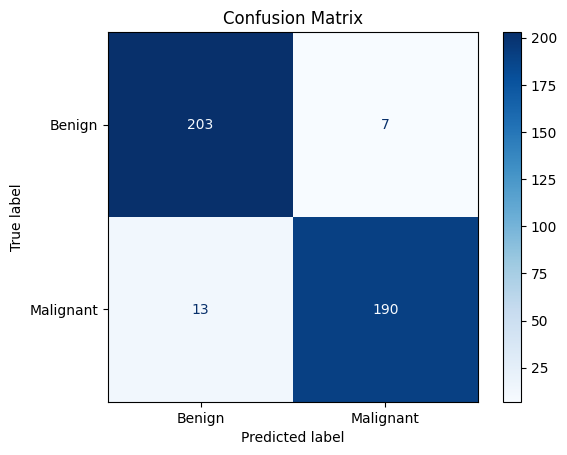

In [ ]:
cm= confusion_matrix(y_true=y_test, y_pred=y_pred_2)
target_names = ["Benign", "Malignant"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased or aa: bool
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  dash_capstyle: `.CapStyle` or {'butt', 'projecting', 'round'}
  dash_joinstyle: `.JoinStyle` or {'miter', 'round', 'bevel'}
  dashes: sequence of floats (on/off ink in points) or (None, None)
  data: (2, N) array or two 1D arrays
  drawstyle or ds: {'default', 'steps', 'steps-pre', 'steps-mid', 'steps-post'}, default: 'default'
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fillstyle: {'full', 'left', 'right', 'bottom', 'top', 'none'}
  gapcolor: :mpltype:`color` or None
  gid: str
  in_layout: bool
  label: object
  linestyle or ls: {'-', '--', '-.', ':', '', (offset, on-off

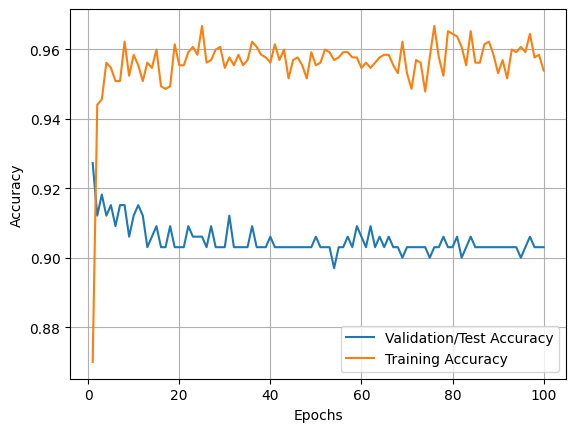

In [ ]:
history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label = 'Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label = 'Training Accuracy')

plt.setp(line1)
plt.setp(line2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased or aa: bool
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  dash_capstyle: `.CapStyle` or {'butt', 'projecting', 'round'}
  dash_joinstyle: `.JoinStyle` or {'miter', 'round', 'bevel'}
  dashes: sequence of floats (on/off ink in points) or (None, None)
  data: (2, N) array or two 1D arrays
  drawstyle or ds: {'default', 'steps', 'steps-pre', 'steps-mid', 'steps-post'}, default: 'default'
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fillstyle: {'full', 'left', 'right', 'bottom', 'top', 'none'}
  gapcolor: :mpltype:`color` or None
  gid: str
  in_layout: bool
  label: object
  linestyle or ls: {'-', '--', '-.', ':', '', (offset, on-off

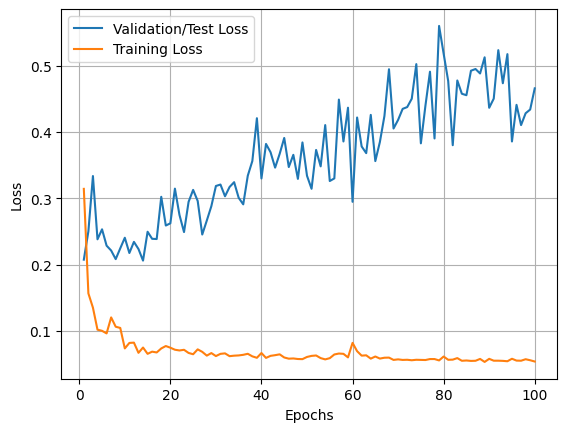

In [ ]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_loss_values, label = 'Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label = 'Training Loss')

plt.setp(line1)
plt.setp(line2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


Saving Bengin case (9).jpg to Bengin case (9).jpg

Processing uploaded image: Bengin case (9).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Class: benign
Confidence: 99.68%


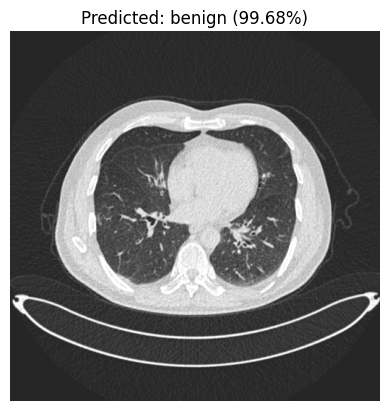

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# Define class names (same as in your dataset)
class_names = ["malignant", "benign"]

# Function to preprocess a single image
def preprocess_image(image_data):
    # Read the image from bytes
    img_array = np.frombuffer(image_data, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)  # Read as BGR
    if img is None:
        raise ValueError("Could not load image")

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 224x224
    img = cv2.resize(img, (224, 224))

    # Normalize pixel values
    img = img / 255.0

    # Reshape to (1, 224, 224, 3) for model input
    img = np.expand_dims(img, axis=0)

    return img, img_array

# Function to predict and display result
def predict_image(model, image_data):
    # Preprocess the image
    processed_img, img_array = preprocess_image(image_data)

    # Make prediction
    predictions = model.predict(processed_img)

    # Get predicted class and confidence
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100  # Convert to percentage

    # Print result
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    # Display the image
    img = cv2.imdecode(np.frombuffer(img_array, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Upload an image
uploaded = files.upload()

# Process the uploaded image
for filename, image_data in uploaded.items():
    print(f"\nProcessing uploaded image: {filename}")
    predict_image(vgg_model, image_data)

# Densenet121

DenseNet121

Description

DenseNet121 is a deeper CNN architecture that uses dense connectivity, where each layer receives inputs from all preceding layers. This design promotes feature reuse, reduces the number of parameters, and enhances gradient flow, making it highly effective for complex image classification tasks.

Why Used for LIDC-IDRI





Rich Feature Extraction: DenseNet121’s dense connectivity captures intricate patterns in lung nodule images, which is crucial for distinguishing subtle differences between malignant and benign nodules.



Robustness: The model’s depth and feature reuse make it well-suited for medical imaging tasks, where high accuracy is critical, and the LIDC-IDRI dataset’s variability (e.g., nodule size, texture) demands robust feature learning.



Transfer Learning: Like MobileNetV2, DenseNet121 leverages ImageNet pre-trained weights, adapting them to the LIDC-IDRI dataset to improve performance on this specialized task.

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable=False

In [ ]:

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import DenseNet121

# Load the pre-trained DenseNet121 model (without top layers)
# base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3))



# We define the number of classes in the classification problem.
NUM_CLASSES = 2

# First, a sequential model is created, which will be used to build the VGG model.
vgg_model = Sequential()

# Se agrega una capa al modelo. base_model el modelo anteriormente preentrenado.
vgg_model.add(base_model)

# A flattening layer (Flatten) is added. This layer converts the output from the
# previous layer (which is likely a three-dimensional tensor) into a one-dimensional vector.
vgg_model.add(layers.Flatten())
dummy_input = tf.zeros((1, 224, 224, 3))
_ = vgg_model(dummy_input)

intermediate_features = vgg_model.layers[-1].output
attention_weights = layers.Dense(1, activation='softmax')(intermediate_features)
attention_weights = layers.Reshape((1, 1, -1))(attention_weights)
attention_output = layers.Multiply()([intermediate_features, attention_weights])


# vgg_model.add(layers.Dropout(0.25))
# vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(128, activation='relu'))
# vgg_model.add(layers.Dense(64, activation='relu'))



vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(512, activation='relu'))

vgg_model.add(layers.Dense(32, activation='relu'))


vgg_model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

# The first layer of the model (base_model) is frozen, so the weights of this layer
# will not be updated during training.
vgg_model.layers[0].trainable = False



vgg_model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,891,106 (75.88 MB)

 Trainable params: 12,853,602 (49.03 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import DenseNet121

# Load the pre-trained DenseNet121 model (without top layers)
# base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3))



# We define the number of classes in the classification problem.
NUM_CLASSES = 2

# First, a sequential model is created, which will be used to build the VGG model.
vgg_model = Sequential()

# Se agrega una capa al modelo. base_model el modelo anteriormente preentrenado.
vgg_model.add(base_model)

# A flattening layer (Flatten) is added. This layer converts the output from the
# previous layer (which is likely a three-dimensional tensor) into a one-dimensional vector.
vgg_model.add(layers.Flatten())
dummy_input = tf.zeros((1, 224, 224, 3))
_ = vgg_model(dummy_input)

intermediate_features = vgg_model.layers[-1].output
attention_weights = layers.Dense(1, activation='softmax')(intermediate_features)
attention_weights = layers.Reshape((1, 1, -1))(attention_weights)
attention_output = layers.Multiply()([intermediate_features, attention_weights])


# vgg_model.add(layers.Dropout(0.25))
# vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(128, activation='relu'))
# vgg_model.add(layers.Dense(64, activation='relu'))



vgg_model.add(layers.Dense(256, activation='relu'))
# vgg_model.add(layers.Dense(512, activation='relu'))

vgg_model.add(layers.Dense(32, activation='relu'))


vgg_model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

# The first layer of the model (base_model) is frozen, so the weights of this layer
# will not be updated during training.
vgg_model.layers[0].trainable = False



vgg_model.summary()






# vgg_model.summary()

optimizer=keras.optimizers.Adam(learning_rate=0.0001)
losses=keras.losses.SparseCategoricalCrossentropy()
metrics=['accuracy']
vgg_model.compile(optimizer=optimizer,loss=losses,metrics=metrics)

epochs=20
batch_size=32
history= vgg_model.fit(X_train,y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,891,106 (75.88 MB)

 Trainable params: 12,853,602 (49.03 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 68s 960ms/step - accuracy: 0.7103 - loss: 0.6397 - val_accuracy: 0.9000 - val_loss: 0.2190
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - accuracy: 0.9373 - loss: 0.1374 - val_accuracy: 0.9121 - val_loss: 0.2065
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9505 - loss: 0.1166 - val_accuracy: 0.9394 - val_loss: 0.1930
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9568 - loss: 0.0906 - val_accuracy: 0.9333 - val_loss: 0.2171
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9567 - loss: 0.1106 - val_accuracy: 0.9121 - val_loss: 0.1637
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9533 - loss: 0.1003 - val_accuracy: 0.9121 - val_loss: 0.2474
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9535 - loss: 0.1260 - val_accuracy: 0.8909 - val_loss: 0.2084
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9585 - loss: 0.0989 - val_accur

In [ ]:

test_loss, test_accuracy = vgg_model.evaluate(X_test,y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)
y_pred = vgg_model.predict(X_test, verbose=1)
y_pred_2 = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_2))


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9633 - loss: 0.0810
Test Loss: 0.11551424860954285
Test Accuracy: 0.9491525292396545
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 993ms/step
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       210
           1       0.93      0.97      0.95       203

    accuracy                           0.95       413
   macro avg       0.95      0.95      0.95       413
weighted avg       0.95      0.95      0.95       413



<function matplotlib.pyplot.show(close=None, block=None)>

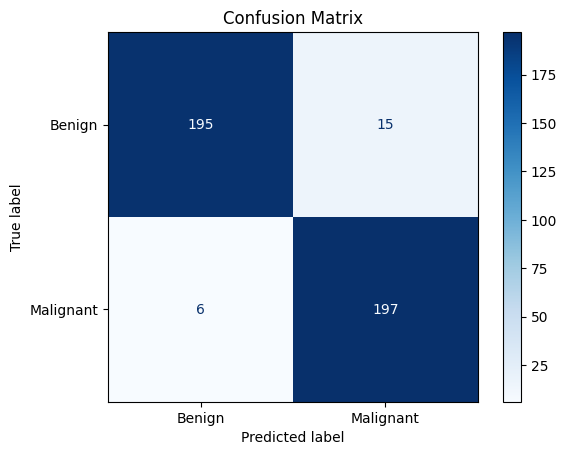

In [ ]:
cm= confusion_matrix(y_true=y_test, y_pred=y_pred_2)
target_names = ["Benign", "Malignant"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased or aa: bool
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  dash_capstyle: `.CapStyle` or {'butt', 'projecting', 'round'}
  dash_joinstyle: `.JoinStyle` or {'miter', 'round', 'bevel'}
  dashes: sequence of floats (on/off ink in points) or (None, None)
  data: (2, N) array or two 1D arrays
  drawstyle or ds: {'default', 'steps', 'steps-pre', 'steps-mid', 'steps-post'}, default: 'default'
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fillstyle: {'full', 'left', 'right', 'bottom', 'top', 'none'}
  gapcolor: :mpltype:`color` or None
  gid: str
  in_layout: bool
  label: object
  linestyle or ls: {'-', '--', '-.', ':', '', (offset, on-off

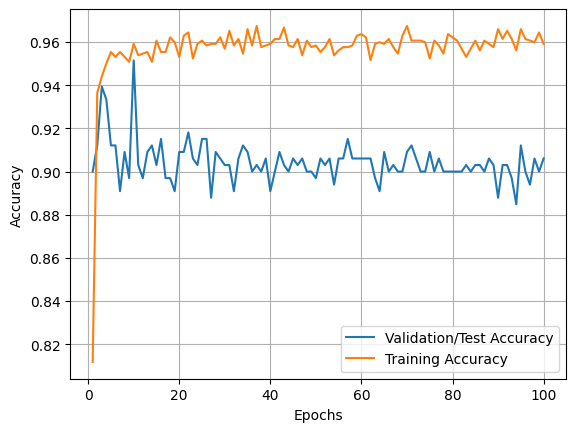

In [ ]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)
line1 = plt.plot(epochs, val_acc_values, label = 'Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label = 'Training Accuracy')
plt.setp(line1)
plt.setp(line2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased or aa: bool
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  dash_capstyle: `.CapStyle` or {'butt', 'projecting', 'round'}
  dash_joinstyle: `.JoinStyle` or {'miter', 'round', 'bevel'}
  dashes: sequence of floats (on/off ink in points) or (None, None)
  data: (2, N) array or two 1D arrays
  drawstyle or ds: {'default', 'steps', 'steps-pre', 'steps-mid', 'steps-post'}, default: 'default'
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fillstyle: {'full', 'left', 'right', 'bottom', 'top', 'none'}
  gapcolor: :mpltype:`color` or None
  gid: str
  in_layout: bool
  label: object
  linestyle or ls: {'-', '--', '-.', ':', '', (offset, on-off

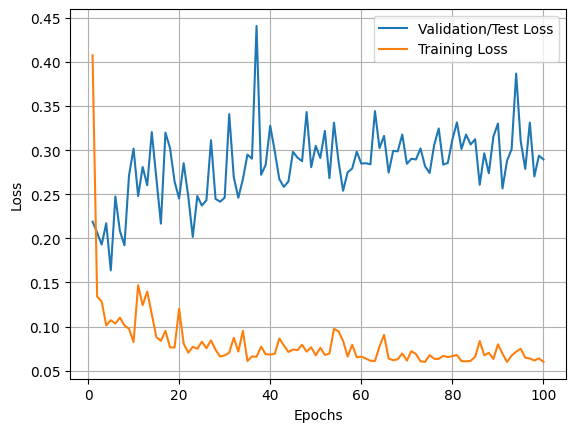

In [ ]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
line1 = plt.plot(epochs, val_loss_values, label = 'Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label = 'Training Loss')
plt.setp(line1)
plt.setp(line2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

Saving Bengin case (9).jpg to Bengin case (9) (1).jpg

Processing uploaded image: Bengin case (9) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: benign
Confidence: 99.68%


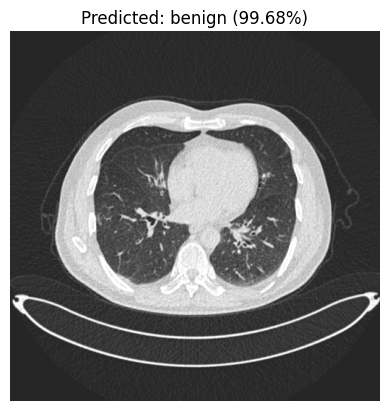

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Define class names (matching your dataset, adjusted to align with evaluation)
class_names = ["malignant", "benign"]

# Function to preprocess a single image
def preprocess_image(image_data):
    # Read the image from bytes
    img_array = np.frombuffer(image_data, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)  # Read as BGR
    if img is None:
        raise ValueError("Could not load image")

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 224x224
    img = cv2.resize(img, (224, 224))

    # Normalize pixel values
    img = img / 255.0

    # Reshape to (1, 224, 224, 3) for model input
    img = np.expand_dims(img, axis=0)

    return img, img_array

# Function to predict and display result
def predict_image(model, image_data):
    # Preprocess the image
    processed_img, img_array = preprocess_image(image_data)

    # Make prediction
    predictions = model.predict(processed_img)

    # Get predicted class and confidence
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100  # Convert to percentage

    # Print result
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    # Display the image
    img = cv2.imdecode(np.frombuffer(img_array, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Upload an image
uploaded = files.upload()

# Process the uploaded image
for filename, image_data in uploaded.items():
    print(f"\nProcessing uploaded image: {filename}")
    predict_image(vgg_model, image_data)

Conclusion

MobileNetV2 and DenseNet121 were selected for their efficiency, robust feature extraction, and compatibility with the LIDC-IDRI dataset’s requirements. MobileNetV2 supports rapid development and deployment, while DenseNet121 offers potential for higher accuracy through deeper feature learning. By leveraging transfer learning and a tailored attention mechanism, both models effectively address the challenge of classifying lung nodules, contributing to reliable diagnostic support